# Feature Importance
Checking which columns matter most for predicting Stress_Level

In [1]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [2]:
# Step 2: Load the already-cleaned data from data/processed/
df = pd.read_csv("../data/processed/student_data_clean.csv")
df.head()

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level,Student_Type_Encoded
0,6.868702,1.711722,3.176942,81.906511,8.0,7.0,2.0,1,1
1,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1,1
2,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1,2
3,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0,1
4,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1,2


In [3]:
# Step 3: Split into x (features) and y (target)
x = df.drop(['Stress_Level'], axis=1)
y = df['Stress_Level']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [4]:
# Step 4: Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [5]:
# Step 5: See feature importance
importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

importance

,feature,importance
4,Exam_Pressure,0.308121
1,Study_Hours,0.159696
0,Sleep_Hours,0.131335
2,Social_Media_Hours,0.127726
3,Attendance,0.118307
6,Month,0.067384
5,Family_Support,0.063661
7,Student_Type_Encoded,0.023769


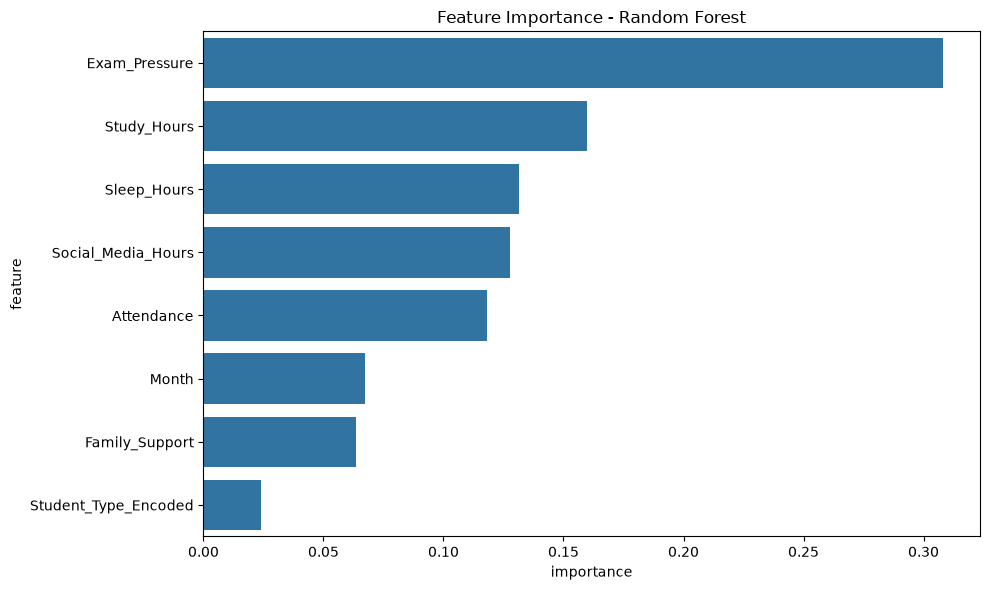

In [6]:
# Step 6: Plot it so it's easier to see
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=importance)
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

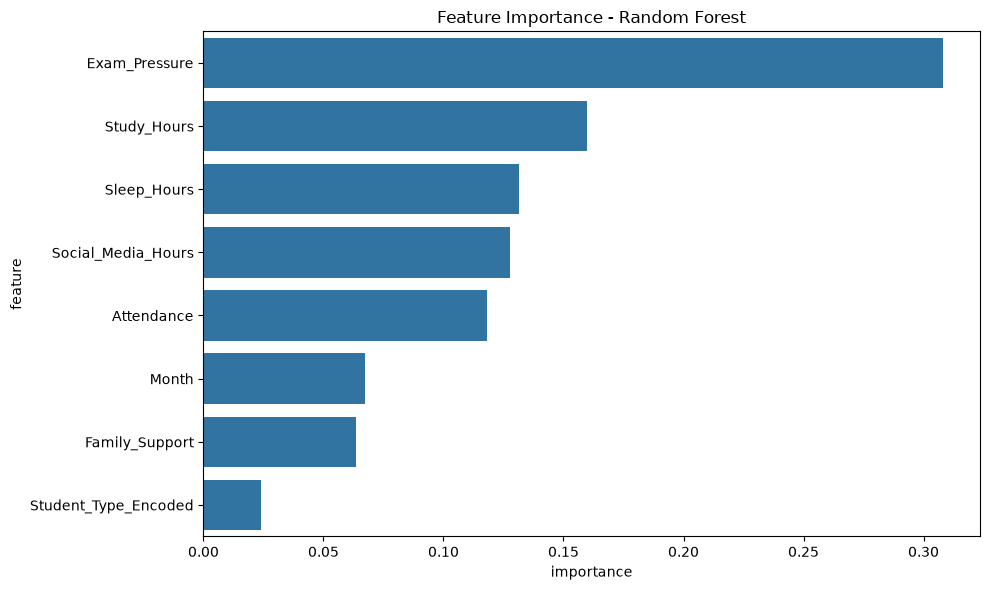

Saved to outputs/feature_importance.png


In [7]:
# Step 7: Save the chart to outputs/ so it's part of the project record
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=importance)
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()
print("Saved to outputs/feature_importance.png")